<a href="https://colab.research.google.com/github/Bryanwang0619/RNN-from-NTHU-math/blob/main/11401%E8%8F%81%E8%8B%B1AI_%E8%94%A1%E5%BF%97%E5%BC%B7RNN1150110.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# You may need to install this: pip install PyMuPDF
!pip install PyMuPDF
import fitz  # PyMuPDF

def read_epub_text(file_path):
    doc = fitz.open(file_path)
    text = ""
    for page in doc:
        text += page.get_text()
    return text

# Replace the raw_text variable with content from your file
filename = "pg1661-images-3.epub"
raw_text = read_epub_text(filename)

# ... continue with the rest of the preprocessing code ...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 81.8 MB/s eta 0:00:00


In [ ]:
from google.colab import files

# The filename to download
filename_to_download = 'The Adventures of Sherlock Holmes.txt'

try:
    files.download(filename_to_download)
    print(f"'{filename_to_download}' has been prepared for download.")
except Exception as e:
    print(f"Error downloading '{filename_to_download}': {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

'output.txt' has been prepared for download.


In [ ]:
output_filename = "output.txt"
with open(output_filename, "w", encoding="utf-8") as f:
    f.write(raw_text)

print(f"Content saved to {output_filename}")

Content saved to output.txt


這段程式碼是一個完整的流程，用於訓練一個基於 RNN (遞迴神經網路) 的詞彙嵌入 (Word Embedding) 模型。它的主要功能是從文本數據中學習詞彙的向量表示，讓語義相似的詞彙在向量空間中也靠得更近。

程式碼主要分為以下幾個部分：

### 1. 數據準備 (Data Preparation)
*   **讀取與清理文本**：首先從 `output.txt` 檔案中讀取文本內容。它嘗試移除 Gutenberg 專案的 Header 和 Footer，只保留故事主體內容。如果檔案找不到，會使用備用文本。
*   **前處理**：將文本轉換為小寫，移除標點符號，並將文本分割成單詞列表。
*   **建立詞彙表 (Vocabulary)**：計算詞頻，選取出現次數最多的詞彙作為模型的詞彙表。這裡設定了 `vocab_size` 為 3000，並加入了 `<UNK>` (Unknown) 標記來處理詞彙表中不存在的詞。
*   **詞彙映射**：建立 `word_to_ix` (詞彙到索引) 和 `ix_to_word` (索引到詞彙) 的映射字典。
*   **N-gram 訓練數據**：將文本轉換為數字索引後，程式碼會根據 `n_gram` 設定（這裡為 3）來製作訓練樣本。每個樣本 `X` 包含 `n_gram` 個連續詞彙的索引，而 `y` 則是緊跟在這些詞彙之後的下一個詞彙的索引（即用前3個詞預測第4個詞）。
*   **批次處理 (Batching)**：為了高效訓練和避免記憶體溢出，使用 PyTorch 的 `DataLoader` 將訓練數據分成小批次 (Batch)，並在訓練時隨機打亂。

### 2. 模型定義 (The Model)
*   **`RNNEmbeddingModel` 類別**：這是一個 PyTorch 的 `nn.Module`，定義了模型的架構。
    *   **`nn.Embedding` 層**：這是核心部分，用於將離散的詞彙索引轉換為密集的向量表示 (即詞彙嵌入)。每個詞彙會被映射到一個 `embed_dim` (這裡是 64) 維的向量。
    *   **`nn.LSTM` 層**：使用 LSTM (長短期記憶網路) 來處理詞彙序列。LSTM 是一種特殊類型的 RNN，能有效捕捉序列中的長期依賴關係，比傳統 RNN 更穩定且訓練效果更好。
    *   **`nn.Linear` 層**：輸出層，將 LSTM 輸出的隱藏狀態轉換為與詞彙表大小 (`vocab_size`) 相同維度的向量，這些值會被用來預測下一個詞彙的機率分佈。
*   **`forward` 方法**：定義了數據如何通過模型。輸入的詞彙索引首先經過 `Embedding` 層，然後進入 `LSTM`，最後通過 `Linear` 層得到輸出。

### 3. 訓練設定 (Training Config)
*   **超參數 (Hyperparameters)**：設定了詞彙嵌入的維度 (`EMBED_DIM`)、LSTM 隱藏層的維度 (`HIDDEN_DIM`)、學習率 (`LR`) 和訓練的輪數 (`EPOCHS`)。這些參數根據數據量進行了調整。
*   **設備選擇**：檢查系統是否有可用的 GPU (`cuda`)，如果沒有則使用 CPU 進行訓練。
*   **模型實例化**：創建 `RNNEmbeddingModel` 的實例，並將其移動到選定的設備上。
*   **損失函數 (Loss Function)**：使用 `nn.CrossEntropyLoss()`，這對於多類別分類任務 (預測下一個詞彙) 是標準選擇。
*   **優化器 (Optimizer)**：使用 `optim.Adam` 優化器來調整模型的權重，以最小化損失函數。

### 4. 開始訓練 (Training Loop)
*   **迭代訓練**：程式碼會循環 `EPOCHS` 次。在每個 Epoch 中，模型會遍歷 `dataloader` 中的所有批次數據。
*   **前向傳播**：對於每個批次，輸入數據會傳遞給模型 (`model(inputs)`) 進行預測，得到 `log_probs` (對數機率)。
*   **計算損失**：使用損失函數計算預測結果與真實目標之間的差異。
*   **反向傳播**：`loss.backward()` 計算模型中每個可訓練參數的梯度。
*   **更新權重**：`optimizer.step()` 根據計算出的梯度更新模型參數，以最小化損失。
*   **重置梯度**：`model.zero_grad()` 在每個批次開始時清零梯度，防止梯度累積。
*   **進度報告**：每個 Epoch 結束時，會打印平均損失，讓您了解訓練的進度。

### 5. 取出並驗證 Embedding (Validation)
*   **獲取詞彙嵌入**：從訓練好的模型中提取 `Embedding` 層的權重，這些權重就是每個詞彙的向量表示。
*   **`get_similarity` 函數**：定義了一個函數來計算兩個詞彙之間的餘弦相似度 (Cosine Similarity)。餘弦相似度衡量了兩個向量方向的相似性，值越接近 1 表示越相似，越接近 -1 表示越不相似。
*   **測試相似度**：程式碼提供了一系列詞彙對（例如 `('man', 'woman')`, `('sherlock', 'holmes')`）來測試模型學習到的詞彙相似性。它會打印出這些詞彙對的相似度分數。

### 6. 視覺化 (Visualization)
*   **t-SNE 降維**：為了將高維的詞彙嵌入 (這裡是 64 維) 視覺化，使用了 `t-SNE` (t-Distributed Stochastic Neighbor Embedding) 算法將選定的 100 個詞彙向量降維到 2 維。
*   **散點圖繪製**：將降維後的 2 維向量繪製成散點圖，每個點代表一個詞彙。每個點旁邊會標註其對應的詞彙。
*   **目的**：這張圖可以幫助我們直觀地觀察模型是否成功地將語義相關的詞彙聚類在一起，例如「偵探」相關的詞彙可能會聚集在圖的一個區域。

總之，這段程式碼實作了一個簡單但功能完整的詞彙嵌入訓練和驗證流程，從原始文本到可視化的詞彙相似度分析。

正在讀取並處理 The Adventures of Sherlock Holmes.txt ...
警告：未找到 Header/Footer 標記，將使用全文。
總字數: 107498
訓練樣本數: 107495
Using device: cpu
Start Training...
Epoch 1/20, Loss: 5.2622
Epoch 2/20, Loss: 4.6057
Epoch 3/20, Loss: 4.2547
Epoch 4/20, Loss: 3.9614
Epoch 5/20, Loss: 3.7143
Epoch 6/20, Loss: 3.5023
Epoch 7/20, Loss: 3.3164
Epoch 8/20, Loss: 3.1627
Epoch 9/20, Loss: 3.0279
Epoch 10/20, Loss: 2.9138
Epoch 11/20, Loss: 2.8179
Epoch 12/20, Loss: 2.7260
Epoch 13/20, Loss: 2.6525
Epoch 14/20, Loss: 2.5876
Epoch 15/20, Loss: 2.5376
Epoch 16/20, Loss: 2.4834
Epoch 17/20, Loss: 2.4384
Epoch 18/20, Loss: 2.4062
Epoch 19/20, Loss: 2.3690
Epoch 20/20, Loss: 2.3425

--- Testing Embeddings ---
Similarity (king, queen): One of the words ('king', 'queen') is not in vocab (<UNK>)
Similarity (man, woman): 0.1635
Similarity (sherlock, holmes): 0.0468
Similarity (holmes, watson): 0.2454
Similarity (king, house): 0.0206
Similarity (sherlock, table): 0.0614

Generating Visualization...


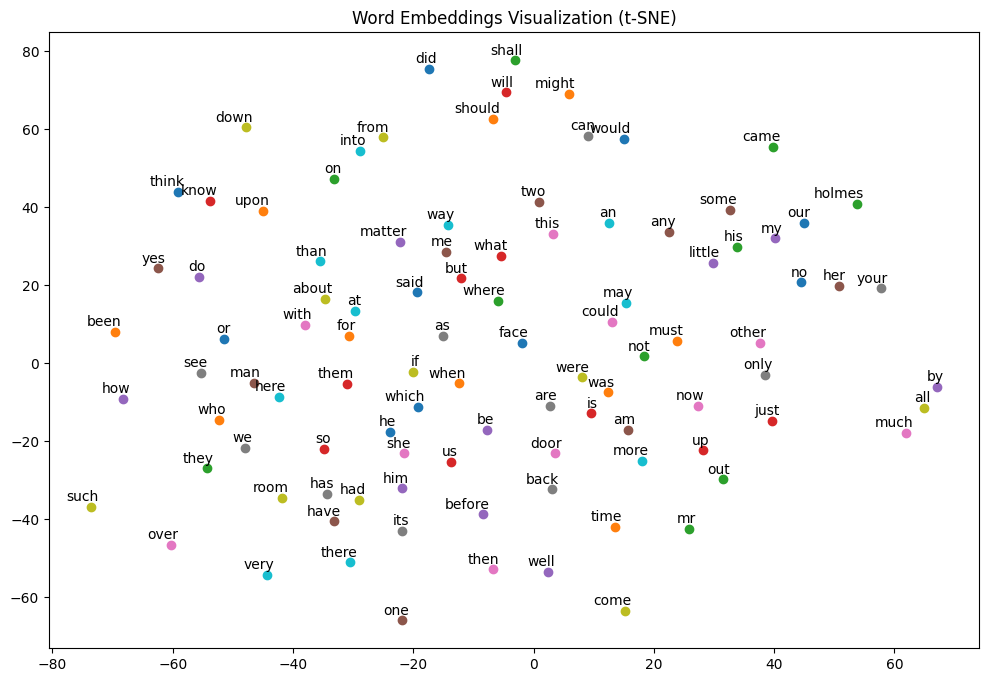

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset # 新增：用於批次訓練
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt # 新增：用於畫圖 (可選)
from sklearn.manifold import TSNE   # 新增：用於降維視覺化 (可選)

# --- 1. 數據準備 (Data Preparation) ---
print("正在讀取並處理 The Adventures of Sherlock Holmes.txt ...")

try:
    # 修正檔案名稱，確保讀取的是 The Adventures of Sherlock Holmes.txt
    with open('/content/drive/MyDrive/Colab Notebooks/The_Adventures_of_Sherlock_Holmes.txt', 'r', encoding='utf-8') as f:
        raw_text = f.read()

    # --- 清理 Gutenberg 的 Header 和 Footer ---
    # 這裡設定關鍵字來切除無關內容，保留故事本體
    start_marker = "A SCANDAL IN BOHEMIA"
    end_marker = "End of the Project Gutenberg"

    start_idx = raw_text.find(start_marker)
    end_idx = raw_text.find(end_marker)

    if start_idx != -1 and end_idx != -1:
        text = raw_text[start_idx : end_idx]
    else:
        text = raw_text
        print("警告：未找到 Header/Footer 標記，將使用全文。")

except FileNotFoundError:
    print("錯誤：找不到 The Adventures of Sherlock Holmes.txt，請確保檔案在正確的路徑下。")
    # 為了不讓程式報錯崩潰，這裡放一個備用假數據
    text = "the king loves the queen " * 1000

# 前處理：轉小寫、去標點
text = text.lower()
text = re.sub(r'[^a-z\s]', '', text)
words = text.split()

print(f"總字數: {len(words)}")

# 建立字典
# 調整參數：詞彙量設為 3000，能覆蓋這本書 90% 以上的內容
vocab_size = 3000
word_counts = Counter(words)
common_words = word_counts.most_common(vocab_size - 1)
vocab = [w[0] for w in common_words]
vocab.append('<UNK>')

word_to_ix = {word: i for i, word in enumerate(vocab)}
ix_to_word = {i: word for i, word in enumerate(vocab)}

# 將文本轉為索引
data_indices = [word_to_ix.get(w, word_to_ix['<UNK>']) for w in words]

# 製作訓練集
# 調整參數：n_gram 改為 3 (用前3個字預測第4個)，提供更多上下文
n_gram = 3
X_data = []
y_data = []

for i in range(len(data_indices) - n_gram):
    X_data.append(data_indices[i : i + n_gram])
    y_data.append(data_indices[i + n_gram])

# 轉換為 Tensor
X_tensor = torch.LongTensor(X_data)
y_tensor = torch.LongTensor(y_data)

# --- 新增：使用 DataLoader 進行批次處理 (Batching) ---
# 因為 10萬筆數據一次塞進模型會記憶體溢出或太慢
BATCH_SIZE = 64
dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"訓練樣本數: {len(X_data)}")

# --- 2. 模型定義 (The Model) ---
class RNNEmbeddingModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(RNNEmbeddingModel, self).__init__()
        # Embedding Layer
        self.embeddings = nn.Embedding(vocab_size, embed_dim)

        # 修改：使用 LSTM 替代 RNN
        # LSTM 更適合處理長序列，訓練更穩定，能學到更好的語義
        self.lstm = nn.LSTM(input_size=embed_dim, hidden_size=hidden_dim, batch_first=True)

        # 輸出層
        self.linear = nn.Linear(hidden_dim, vocab_size)

    def forward(self, inputs):
        embeds = self.embeddings(inputs)

        # LSTM 輸出格式為 (output, (hidden, cell))
        # 我們只需要 output
        out, _ = self.lstm(embeds)

        # 取最後一個時間點的輸出
        final_out = self.linear(out[:, -1, :])
        return final_out

# --- 3. 訓練設定 (Training Config) ---
# 調整參數：針對 10萬字文本的建議設定
EMBED_DIM = 64      # 增加維度以捕捉更多語義
HIDDEN_DIM = 128    # 增加隱藏層寬度
LR = 0.005          # 稍微降低學習率以求穩定
EPOCHS = 20         # 20 Epochs 對這本書通常足夠

# 檢查是否有 GPU，否則用 CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = RNNEmbeddingModel(len(vocab), EMBED_DIM, HIDDEN_DIM).to(device)
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# --- 4. 開始訓練 (Training Loop) ---
print("Start Training...")

for epoch in range(EPOCHS):
    total_loss = 0
    model.train()

    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)

        model.zero_grad()
        log_probs = model(inputs)
        loss = loss_function(log_probs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}")

# --- 5. 取出並驗證 Embedding (Validation) ---
print("\n--- Testing Embeddings ---")

# 將 Embedding 權重移回 CPU 並轉為 Numpy
trained_embeddings = model.embeddings.weight.data.cpu()

def get_similarity(word1, word2):
    if word1 not in word_to_ix or word2 not in word_to_ix:
        return f"One of the words ('{word1}', '{word2}') is not in vocab (<UNK>)"

    id1 = word_to_ix[word1]
    id2 = word_to_ix[word2]

    vec1 = trained_embeddings[id1]
    vec2 = trained_embeddings[id2]

    # 計算 Cosine Similarity
    cos = nn.CosineSimilarity(dim=0)
    return cos(vec1, vec2).item()

# 測試一些福爾摩斯相關的詞彙
pairs = [
    ('king', 'queen'),
    ('man', 'woman'),
    ('sherlock', 'holmes'),
    ('holmes', 'watson'),
    ('king', 'house'), # 應該比較低
    ('sherlock', 'table') # 應該比較低
]

for w1, w2 in pairs:
    similarity_result = get_similarity(w1, w2)
    if isinstance(similarity_result, str):
        print(f"Similarity ({w1}, {w2}): {similarity_result}")
    else:
        print(f"Similarity ({w1}, {w2}): {similarity_result:.4f}")

# --- 6. (加碼) 視覺化 Visualization ---
# 隨機選取 100 個字來畫圖，看看分佈
try:
    print("\nGenerating Visualization...")
    vis_words = vocab[10:110] # 跳過一些太常見的停用詞
    vis_indices = [word_to_ix[w] for w in vis_words]
    vis_vecs = trained_embeddings[vis_indices].numpy()

    # 使用 t-SNE 將 64維 降到 2維
    tsne = TSNE(n_components=2, random_state=42, perplexity=10)
    reduced_vecs = tsne.fit_transform(vis_vecs)

    plt.figure(figsize=(12, 8))
    for i, word in enumerate(vis_words):
        x, y = reduced_vecs[i]
        plt.scatter(x, y)
        plt.annotate(word, xy=(x, y), xytext=(5, 2), textcoords='offset points', ha='right', va='bottom')
    plt.title("Word Embeddings Visualization (t-SNE)")
    plt.show()
except Exception as e:
    print(f"Visualization skipped: {e}")

In [ ]:
import torch
from google.colab import files

# Define the filename for the saved model
model_filename = "rnn_embedding_model.pth"

# Ensure the 'model' object is defined.
# The 'model' object is defined and trained in cell U3hC1Qqdp3p.
# Please ensure that cell (U3hC1Qqdp3p) has been executed successfully before running this cell.
if 'model' not in locals() and 'model' not in globals():
    print("Error: 'model' is not defined. Please run the training cell (U3hC1Qqdp3p) first to define and train the model.")
else:
    try:
        # Save the model's state dictionary
        torch.save(model.state_dict(), model_filename)
        print(f"Model saved to {model_filename}")

        # Download the model file
        files.download(model_filename)
    except Exception as e:
        print(f"An error occurred while saving/downloading the model: {e}")

Model saved to rnn_embedding_model.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 重新定義模型架構及重建詞彙表

由於 Colab 環境重新啟動會清除所有記憶體中的變數和類別定義，我們需要重新定義 `RNNEmbeddingModel` 類別，並且重建訓練時所使用的詞彙表 (`word_to_ix`, `ix_to_word`) 和其他超參數 (`vocab_size`, `EMBED_DIM`, `HIDDEN_DIM`, `device`)，以確保模型能夠正確載入並運作。我們將重新執行原始訓練程式碼中負責這些部分的片段。

**請注意：** 為了確保模型的相容性，這裡的數據預處理和詞彙表建立必須與訓練模型時使用的完全一致。

### 執行文字生成器

接下來，我們將使用您提供的 `generate_sentence` 函數，配合載入的模型來生成文本。

### 載入模型

現在我們將創建一個新的模型實例，並從 `rnn_embedding_model.pth` 檔案中載入之前訓練好的權重。
### 重新定義模型架構及重建詞彙表

由於 Colab 環境重新啟動會清除所有記憶體中的變數和類別定義，我們需要重新定義 `RNNEmbeddingModel` 類別，並且重建訓練時所使用的詞彙表 (`word_to_ix`, `ix_to_word`) 和其他超參數 (`vocab_size`, `EMBED_DIM`, `HIDDEN_DIM`, `device`)，以確保模型能夠正確載入並運作。我們將重新執行原始訓練程式碼中負責這些部分的片段。

**請注意：** 為了確保模型的相容性，這裡的數據預處理和詞彙表建立必須與訓練模型時使用的完全一致。

In [ ]:
# 載入文字生成所需的函式庫
import torch
import torch.nn as nn
import re
from collections import Counter
import numpy as np

In [ ]:
# 實例化模型 (使用重建的 vocab_size, EMBED_DIM, HIDDEN_DIM)
model = RNNEmbeddingModel(len(vocab), EMBED_DIM, HIDDEN_DIM).to(device)

# 定義模型檔案名稱，指向 Google Drive 中的路徑
model_filename = "/content/drive/MyDrive/Colab Notebooks/rnn_embedding_model.pth"

try:
    # 載入模型的權重 (state_dict)
    # map_location='cpu' 可以確保即使模型是在 GPU 上訓練的，也能在 CPU 上載入。
    model.load_state_dict(torch.load(model_filename, map_location=device))
    model.eval() # 設定為評估模式
    print(f"模型 '{model_filename}' 成功載入！")
except FileNotFoundError:
    print(f"錯誤：找不到模型檔案 '{model_filename}'。請確保檔案存在。")
except Exception as e:
    print(f"載入模型時發生錯誤: {e}")

模型 '/content/drive/MyDrive/Colab Notebooks/rnn_embedding_model.pth' 成功載入！


In [ ]:
# --- 7. (應用) 實戰：文字生成器 (Text Generator) ---
print("\n--- Application: Text Generation ---")

# 無需再次進行數據準備，直接使用 U3hC1QWqdp3p 中已建立的全局變數
# import re # 已在 U3hC1QWqdp3p 中導入
# from collections import Counter # 已在 U3hC1QWqdp3p 中導入
# import torch # 已在 U3hC1QWqdp3p 中導入

# 以下為 generate_sentence 函數，確保其正確使用全局變數
def generate_sentence(model_to_use, start_words, max_length=20):
    # 將模型切換到推論模式，這會關閉 dropout 等僅在訓練時啟用的層。
    model_to_use.eval()

    # 預處理輸入文字：轉換為小寫並分割成單詞列表
    words = start_words.lower().split()
    # 將單詞轉換為對應的索引。如果單詞不在詞彙表中，則使用 <UNK> (未知詞彙) 的索引。
    # 注意：這裡使用全局的 word_to_ix
    current_indices = [word_to_ix.get(w, word_to_ix['<UNK>']) for w in words]

    # 將索引列表轉換為 PyTorch 的 LongTensor，並增加一個批次 (batch) 維度 (1, seq_len)。
    # 注意：這裡使用全局的 device
    input_tensor = torch.LongTensor([current_indices]).to(device)

    # 初始化已生成詞彙列表
    generated_words = list(words)

    # 在推論模式下，不需要計算梯度，可以節省記憶體和加速計算。
    with torch.no_grad():
        # 循環生成直到達到最大長度
        for _ in range(max_length):
            # 1. 將當前輸入傳遞給模型進行預測
            output = model_to_use(input_tensor)

            # 2. 找出機率最高的下一個詞彙的索引 (Greedy Search)
            # 您也可以使用 torch.multinomial 進行隨機採樣，使生成的句子更具多樣性。
            predicted_index = torch.argmax(output, dim=1).item()
            # 將預測的索引轉換回實際的詞彙字符串
            # 注意：這裡使用全局的 ix_to_word
            predicted_word = ix_to_word[predicted_index]

            # 3. 將預測的詞彙添加到已生成詞彙列表中
            generated_words.append(predicted_word)

            # 4. 更新輸入序列：將新的預測詞彙索引添加到序列中，作為下一次預測的上下文。
            # (LSTM 可以處理變長序列，所以直接在 current_indices 後追加即可)
            current_indices.append(predicted_index)
            # 為了符合模型期望的輸入 n_gram 數量，我們只保留最後 n_gram 個詞。
            # 在這個模型中，LSTM 可以處理變長序列，所以可以直接追加，但是如果模型的 forward 邏輯
            # 是固定 n_gram，則需要調整。這裡假定 LSTM 可以處理。
            # 由於我們沒有 N_GRAM 變數，且模型是 LSTM，我們保持每次預測使用完整序列。但為了避免序列過長導致記憶體問題或影響效果，
            # 一般會取最後 N 個詞作為上下文。這裡我們暫時讓它使用完整序列。
            # 如果需要固定上下文，可以這樣修改：
            # if len(current_indices) > n_gram: current_indices = current_indices[-n_gram:]
            # input_tensor = torch.LongTensor([current_indices]).to(device)
            input_tensor = torch.LongTensor([current_indices]).to(device)

            # 可以根據需要添加條件來停止生成，例如預測到句尾標記等。

    # 將所有生成的詞彙連接成一個句子並返回
    return " ".join(generated_words)

# 設定一些起始短語來測試文本生成功能
start_phrases = ["the man", "sherlock", "i am", "the king"]

print("模型試著模仿福爾摩斯的語氣續寫句子")
for phrase in start_phrases:
    # 確保模型物件已載入並在正確的設備上
    if 'model' in globals() and model is not None:
        generated_text = generate_sentence(model, phrase)
        print(f"起始短語: '{phrase}' -> 生成結果: '{generated_text}'")
    else:
        print("錯誤: 模型未載入，無法進行文本生成。")


--- Application: Text Generation ---
模型試著模仿福爾摩斯的語氣續寫句子
起始短語: 'the man' -> 生成結果: 'the man sat huddled up in his hand pulled purely nominal services now he asked not a few <UNK> about the <UNK>'
起始短語: 'sherlock' -> 生成結果: 'sherlock holmes for solution during the day i had no idea but still raised the <UNK> to his address and that'
起始短語: 'i am' -> 生成結果: 'i am afraid that you were <UNK> with her about that when he is the <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK>'
起始短語: 'the king' -> 生成結果: 'the king of bohemia in below there and the black jack of impressions i have come to england i had nothing fit'
